# 🥇 GOLD LAYER — K-Means Clustering, Evaluasi, dan Analisis ASEAN

**Tujuan:** Mengelompokkan 217 negara berdasarkan 4 indikator SDG 5 menggunakan K-Means, mengevaluasi kualitas cluster, dan menganalisis posisi negara ASEAN.

| Input | Output |
|-------|--------|
| `/data/silver/sdg5_normalized.parquet` | `/data/gold/clustering_result.parquet` |
| 217 negara × 4 indikator (0-1) | `/data/gold/clustering_result.csv` |
| | `/data/gold/elbow_chart.png` |
| | `/data/gold/silhouette_chart.png` |

**Pipeline:** Load → Elbow Method → Silhouette → K-Means (k=4) → Evaluasi → PCA → ASEAN → Save

In [10]:
# ============================================================
# STEP 1 — LOAD DATA SILVER & SETUP
# ============================================================
from pyspark.sql import SparkSession
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.decomposition import PCA

# Inisialisasi Spark (local mode)
spark = SparkSession.builder \
    .appName("SDG5-Gender-Analysis") \
    .master("local[*]") \
    .config("spark.driver.memory", "2g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .config("mapreduce.fileoutputcommitter.marksuccessfuljobs", "false") \
    .config("mapreduce.fileoutputcommitter.algorithm.version", "2") \
    .getOrCreate()

# Load dari Silver
df_silver_spark = spark.read.parquet("/data/silver/sdg5_normalized.parquet")
df = df_silver_spark.toPandas()

FEATURES = [
    "SP.ADO.TFRT",       # Adolescent Fertility Rate
    "SH.STA.MMRT",       # Maternal Mortality Ratio
    "SG.GEN.PARL.ZS",    # Women in Parliament (%)
    "SL.TLF.ACTI.FE.ZS"  # Female Labor Force Participation (%)
]

X = df[FEATURES].values

print("✅ Data Silver berhasil dimuat")
print(f"Matrix shape: {X.shape}")
print(f"Negara: {len(df)}")
print(f"Fitur: {len(FEATURES)}")
print(f"\nStatistik deskriptif (sudah dinormalisasi 0-1):")
print(df[FEATURES].describe().round(3).to_string())

✅ Data Silver berhasil dimuat
Matrix shape: (212, 4)
Negara: 212
Fitur: 4

Statistik deskriptif (sudah dinormalisasi 0-1):
       SP.ADO.TFRT  SH.STA.MMRT  SG.GEN.PARL.ZS  SL.TLF.ACTI.FE.ZS
count      212.000      212.000         212.000            212.000
mean         0.262        0.116           0.361              0.652
std          0.240        0.175           0.185              0.198
min          0.000        0.000           0.000              0.000
25%          0.061        0.012           0.219              0.569
50%          0.191        0.051           0.352              0.686
75%          0.402        0.146           0.459              0.783
max          1.000        1.000           1.000              1.000


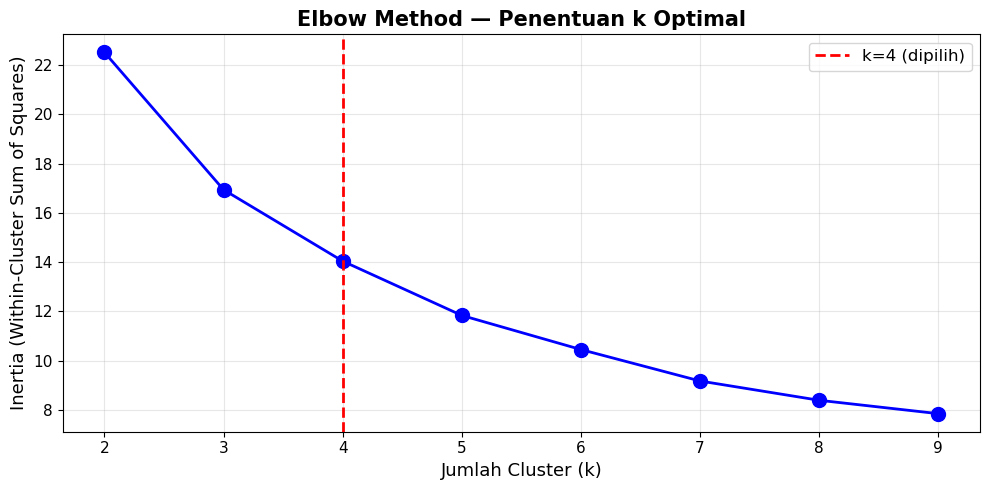


Inertia per k:
  k=2: 22.52
  k=3: 16.94
  k=4: 14.04 ◀ DIPILIH
  k=5: 11.84
  k=6: 10.45
  k=7: 9.17
  k=8: 8.39
  k=9: 7.85

📸 Simpan screenshot chart ini untuk laporan!


In [11]:
# ============================================================
# STEP 2 — ELBOW METHOD (Tentukan k Optimal)
# ============================================================
inertias = []
K_RANGE = range(2, 10)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    km.fit(X)
    inertias.append(km.inertia_)

# Plot Elbow Chart
plt.figure(figsize=(10, 5))
plt.plot(K_RANGE, inertias, 'bo-', linewidth=2, markersize=10)
plt.xlabel("Jumlah Cluster (k)", fontsize=13)
plt.ylabel("Inertia (Within-Cluster Sum of Squares)", fontsize=13)
plt.title("Elbow Method — Penentuan k Optimal", fontsize=15, fontweight='bold')
plt.xticks(K_RANGE, fontsize=11)
plt.yticks(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axvline(x=4, color='red', linestyle='--', linewidth=2, label='k=4 (dipilih)')
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("/data/gold/elbow_chart.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nInertia per k:")
for k, inertia in zip(K_RANGE, inertias):
    marker = " ◀ DIPILIH" if k == 4 else ""
    print(f"  k={k}: {inertia:.2f}{marker}")
print("\n📸 Simpan screenshot chart ini untuk laporan!")

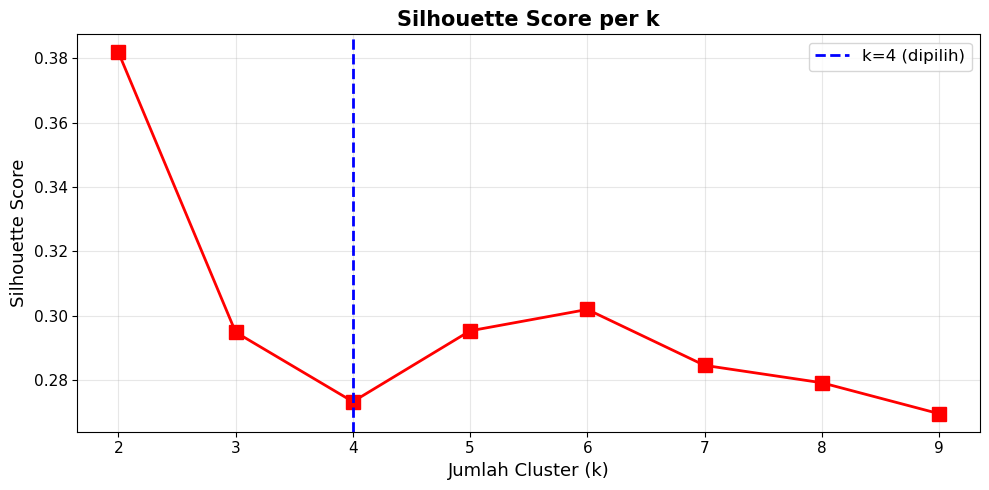


Silhouette Score per k:
  k=2: 0.3818
  k=3: 0.2948
  k=4: 0.2732 ◀ DIPILIH
  k=5: 0.2953
  k=6: 0.3019
  k=7: 0.2845
  k=8: 0.2791
  k=9: 0.2695

💡 Catatan: k=2 memiliki silhouette tertinggi, tapi terlalu kasar.
   k=4 dipilih karena memberikan granularitas lebih baik untuk analisis.

📸 Simpan screenshot chart ini untuk laporan!


In [12]:
# ============================================================
# STEP 3 — SILHOUETTE SCORE per k
# ============================================================
sil_scores = []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    sil = silhouette_score(X, labels)
    sil_scores.append(sil)

# Plot Silhouette
plt.figure(figsize=(10, 5))
plt.plot(K_RANGE, sil_scores, 'rs-', linewidth=2, markersize=10)
plt.xlabel("Jumlah Cluster (k)", fontsize=13)
plt.ylabel("Silhouette Score", fontsize=13)
plt.title("Silhouette Score per k", fontsize=15, fontweight='bold')
plt.xticks(K_RANGE, fontsize=11)
plt.yticks(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axvline(x=4, color='blue', linestyle='--', linewidth=2, label='k=4 (dipilih)')
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("/data/gold/silhouette_chart.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nSilhouette Score per k:")
for k, s in zip(K_RANGE, sil_scores):
    marker = " ◀ DIPILIH" if k == 4 else ""
    print(f"  k={k}: {s:.4f}{marker}")

print("\n💡 Catatan: k=2 memiliki silhouette tertinggi, tapi terlalu kasar.")
print("   k=4 dipilih karena memberikan granularitas lebih baik untuk analisis.")
print("\n📸 Simpan screenshot chart ini untuk laporan!")

In [13]:
# ============================================================
# STEP 4 — K-MEANS FINAL (k=4)
# ============================================================
km_final = KMeans(n_clusters=4, random_state=42, n_init=10, max_iter=300)
df["cluster"] = km_final.fit_predict(X)

print("=" * 50)
print("HASIL K-MEANS CLUSTERING (k=4)")
print("=" * 50)
print("\nDistribusi cluster:")
dist = df["cluster"].value_counts().sort_index()
for cluster_id, count in dist.items():
    print(f"  Cluster {cluster_id}: {count} negara")
print(f"  Total: {dist.sum()} negara")

HASIL K-MEANS CLUSTERING (k=4)

Distribusi cluster:
  Cluster 0: 61 negara
  Cluster 1: 29 negara
  Cluster 2: 42 negara
  Cluster 3: 80 negara
  Total: 212 negara


In [14]:
# ============================================================
# STEP 5 — EVALUASI CLUSTERING
# ============================================================
labels = df["cluster"].values
sil = silhouette_score(X, labels)
dbi = davies_bouldin_score(X, labels)
chi = calinski_harabasz_score(X, labels)

print("=" * 55)
print("  EVALUASI CLUSTERING K-MEANS (k=4)")
print("=" * 55)
print(f"  Silhouette Score       : {sil:.4f}")
print(f"  Davies-Bouldin Index   : {dbi:.4f}  (semakin rendah = semakin baik)")
print(f"  Calinski-Harabasz Index: {chi:.2f}  (semakin tinggi = semakin baik)")
print("=" * 55)

print("\n💡 Interpretasi:")
print(f"  • Silhouette {sil:.2f}: Wajar untuk data sosial/demografis.")
print(f"    Negara berada di spektrum kontinum, bukan kelompok terpisah tajam.")
print(f"  • DBI {dbi:.2f}: Di bawah 1.5 → cluster cukup kompak dan terpisah.")
print(f"  • CHI {chi:.0f}: Semakin tinggi → cluster memiliki densitas dan separasi memadai.")

print("\n" + "=" * 55)
print("  VALIDASI EKSTERNAL — Cluster vs Income Group")
print("=" * 55)
crosstab = pd.crosstab(df["cluster"], df["Income Group"])
print(crosstab.to_string())

print("\n📸 SCREENSHOT BAGIAN INI UNTUK LAPORAN — Ini bukti cluster bermakna!")

  EVALUASI CLUSTERING K-MEANS (k=4)
  Silhouette Score       : 0.2732
  Davies-Bouldin Index   : 1.1657  (semakin rendah = semakin baik)
  Calinski-Harabasz Index: 99.09  (semakin tinggi = semakin baik)

💡 Interpretasi:
  • Silhouette 0.27: Wajar untuk data sosial/demografis.
    Negara berada di spektrum kontinum, bukan kelompok terpisah tajam.
  • DBI 1.17: Di bawah 1.5 → cluster cukup kompak dan terpisah.
  • CHI 99: Semakin tinggi → cluster memiliki densitas dan separasi memadai.

  VALIDASI EKSTERNAL — Cluster vs Income Group
Income Group  High income  Low income  Lower middle income  Upper middle income
cluster                                                                        
0                      38           2                    5                   15
1                       1          17                   10                    1
2                       4           4                   20                   13
3                      43           1                   12     

In [15]:
# ============================================================
# STEP 6 — BERI LABEL NARATIF CLUSTER
# ============================================================
# Profil rata-rata per cluster untuk menentukan label
print("PROFIL RATA-RATA TIAP CLUSTER (nilai ternormalisasi 0-1):")
print(df.groupby("cluster")[FEATURES].mean().round(3).to_string())

# Beri label berdasarkan profil AKTUAL (K-Means memberi nomor acak)
# Cluster 0: Fertilitas rendah, MMR rendah, Parlemen TINGGI, LFP tinggi → Progresif
# Cluster 1: Fertilitas TINGGI, MMR TINGGI, Parlemen sedang, LFP tinggi → Kritis
# Cluster 2: Fertilitas sedang, MMR rendah, Parlemen rendah, LFP RENDAH → Rentan
# Cluster 3: Fertilitas rendah, MMR rendah, Parlemen rendah, LFP tinggi → Berkembang
CLUSTER_LABELS = {
    0: "Progresif \u2014 Kesetaraan Terbaik",
    1: "Kritis \u2014 MMR & Fertilitas Tinggi",
    2: "Rentan \u2014 Partisipasi Perempuan Rendah",
    3: "Berkembang Stabil"
}

df["cluster_label"] = df["cluster"].map(CLUSTER_LABELS)

print("\n" + "=" * 60)
print("LABEL CLUSTER")
print("=" * 60)

feature_labels = {
    "SP.ADO.TFRT": "Adolescent Fertility Rate",
    "SH.STA.MMRT": "Maternal Mortality Ratio",
    "SG.GEN.PARL.ZS": "Women in Parliament (%)",
    "SL.TLF.ACTI.FE.ZS": "Female LFP (%)"
}

for cluster_id in sorted(CLUSTER_LABELS.keys()):
    label = CLUSTER_LABELS[cluster_id]
    count = (df["cluster"] == cluster_id).sum()
    profile = df[df["cluster"] == cluster_id][FEATURES].mean()
    print(f"\n  Cluster {cluster_id}: {label} ({count} negara)")
    for feat in FEATURES:
        print(f"    {feature_labels[feat]}: {profile[feat]:.3f}")

PROFIL RATA-RATA TIAP CLUSTER (nilai ternormalisasi 0-1):
         SP.ADO.TFRT  SH.STA.MMRT  SG.GEN.PARL.ZS  SL.TLF.ACTI.FE.ZS
cluster                                                             
0              0.130        0.041           0.566              0.769
1              0.719        0.443           0.309              0.723
2              0.286        0.102           0.307              0.347
3              0.183        0.062           0.253              0.697

LABEL CLUSTER

  Cluster 0: Progresif — Kesetaraan Terbaik (61 negara)
    Adolescent Fertility Rate: 0.130
    Maternal Mortality Ratio: 0.041
    Women in Parliament (%): 0.566
    Female LFP (%): 0.769

  Cluster 1: Kritis — MMR & Fertilitas Tinggi (29 negara)
    Adolescent Fertility Rate: 0.719
    Maternal Mortality Ratio: 0.443
    Women in Parliament (%): 0.309
    Female LFP (%): 0.723

  Cluster 2: Rentan — Partisipasi Perempuan Rendah (42 negara)
    Adolescent Fertility Rate: 0.286
    Maternal Mortality Ratio

In [16]:
# ============================================================
# STEP 7 — PCA UNTUK VISUALISASI 2D
# ============================================================
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

df["PC1"] = X_pca[:, 0]
df["PC2"] = X_pca[:, 1]

print("=" * 50)
print("PCA — Reduksi Dimensi ke 2D")
print("=" * 50)
print(f"Explained variance:")
print(f"  PC1: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"  PC2: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"  Total: {sum(pca.explained_variance_ratio_)*100:.1f}%")

print(f"\nKomponen PCA (loading):")
pca_df = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=[feature_labels[f] for f in FEATURES]
)
print(pca_df.round(3).to_string())

PCA — Reduksi Dimensi ke 2D
Explained variance:
  PC1: 48.7%
  PC2: 27.3%
  Total: 76.1%

Komponen PCA (loading):
                             PC1    PC2
Adolescent Fertility Rate  0.818 -0.157
Maternal Mortality Ratio   0.534 -0.127
Women in Parliament (%)   -0.175 -0.550
Female LFP (%)            -0.124 -0.811


In [17]:
# ============================================================
# STEP 8 — ANALISIS ASEAN
# ============================================================
ASEAN_CODES = ['IDN', 'MYS', 'SGP', 'THA', 'PHL', 'VNM', 'MMR', 'KHM', 'LAO', 'BRN', 'TLS']
df["is_asean"] = df["Country Code"].isin(ASEAN_CODES)

df_asean = df[df["is_asean"] == True][
    ["Country Name", "Country Code", "Income Group", "cluster", "cluster_label"] + FEATURES
].sort_values("cluster")

asean_count = df["is_asean"].sum()

print("=" * 70)
print(f"  POSISI {asean_count} NEGARA ASEAN DALAM CLUSTER GLOBAL")
print("=" * 70)

# Cek negara ASEAN yang tidak ada di dataset
missing_asean = [c for c in ASEAN_CODES if c not in df["Country Code"].values]
if missing_asean:
    print(f"\n  ⚠️  Negara ASEAN tidak tersedia di dataset: {missing_asean}")
    print("     (Tidak ada data untuk keempat indikator SDG 5 periode 2015-2022)\n")

for _, row in df_asean.iterrows():
    print(f"  {row['Country Name']:25s} | {row['Income Group']:18s} | "
          f"Cluster {row['cluster']} \u2014 {row['cluster_label']}")

print("\n" + "=" * 70)
print("  DETAIL INDIKATOR ASEAN (nilai ternormalisasi)")
print("=" * 70)
print(df_asean[["Country Name", "cluster"] + FEATURES].round(3).to_string(index=False))

print("\n" + "=" * 70)
print("  TEMUAN MENARIK")
print("=" * 70)

# Temuan dinamis berdasarkan data aktual
progresif = df_asean[df_asean["cluster_label"].str.contains("Progresif")]
kritis = df_asean[df_asean["cluster_label"].str.contains("Kritis")]

if len(progresif) > 0:
    print(f"\n  📗 Negara ASEAN di cluster Progresif ({len(progresif)}):")
    for _, row in progresif.iterrows():
        print(f"     • {row['Country Name']} ({row['Income Group']})")

if len(kritis) > 0:
    print(f"\n  📕 Negara ASEAN di cluster Kritis ({len(kritis)}):")
    for _, row in kritis.iterrows():
        print(f"     • {row['Country Name']} ({row['Income Group']})")

print("\n📸 SCREENSHOT TABEL INI UNTUK LAPORAN & INFOGRAFIS!")

  POSISI 10 NEGARA ASEAN DALAM CLUSTER GLOBAL

  ⚠️  Negara ASEAN tidak tersedia di dataset: ['MMR']
     (Tidak ada data untuk keempat indikator SDG 5 periode 2015-2022)

  Viet Nam                  | Lower middle income | Cluster 0 — Progresif — Kesetaraan Terbaik
  Singapore                 | High income        | Cluster 0 — Progresif — Kesetaraan Terbaik
  Timor-Leste               | Lower middle income | Cluster 0 — Progresif — Kesetaraan Terbaik
  Philippines               | Lower middle income | Cluster 2 — Rentan — Partisipasi Perempuan Rendah
  Brunei Darussalam         | High income        | Cluster 3 — Berkembang Stabil
  Indonesia                 | Upper middle income | Cluster 3 — Berkembang Stabil
  Malaysia                  | Upper middle income | Cluster 3 — Berkembang Stabil
  Lao PDR                   | Lower middle income | Cluster 3 — Berkembang Stabil
  Cambodia                  | Lower middle income | Cluster 3 — Berkembang Stabil
  Thailand                  | Upp

In [18]:
# ============================================================
# STEP 9 — SIMPAN OUTPUT GOLD
# ============================================================
# Simpan ke Parquet via Spark
df_gold_spark = spark.createDataFrame(df)
df_gold_spark.write.mode("overwrite").parquet("/data/gold/clustering_result.parquet")

# Export CSV untuk kemudahan visualisasi
df.to_csv("/data/gold/clustering_result.csv", index=False)

print("=" * 50)
print("✅ GOLD LAYER SELESAI")
print("=" * 50)
print(f"Output Parquet: /data/gold/clustering_result.parquet")
print(f"Output CSV    : /data/gold/clustering_result.csv")
print(f"Charts        : /data/gold/elbow_chart.png")
print(f"              : /data/gold/silhouette_chart.png")
print(f"Total negara  : {len(df)}")
print(f"ASEAN         : {df['is_asean'].sum()}")
print(f"Kolom         : {list(df.columns)}")

✅ GOLD LAYER SELESAI
Output Parquet: /data/gold/clustering_result.parquet
Output CSV    : /data/gold/clustering_result.csv
Charts        : /data/gold/elbow_chart.png
              : /data/gold/silhouette_chart.png
Total negara  : 212
ASEAN         : 10
Kolom         : ['Country Code', 'Country Name', 'Region', 'Income Group', 'SP.ADO.TFRT', 'SH.STA.MMRT', 'SG.GEN.PARL.ZS', 'SL.TLF.ACTI.FE.ZS', 'cluster', 'cluster_label', 'PC1', 'PC2', 'is_asean']
